# Micronet figure for Collis et al. 2025 (Bulletin of the American Meteorological Society, currently in review.)

## Concat all of the required files for UIC

In [1]:
import xarray as xr
from pathlib import Path

# Configuration
station = "UIC"
dates_of_interest = ["20240722", "20240723", "20240727", "20240728"]
base_path = "/nfs/gce/projects/crocus/data/ingested-data/long-term-sites"

# Build path for UIC
station_lower = station.lower()
station_path = Path(base_path) / station_lower / f"{station_lower}-wxt-a1"

# Gather matching NetCDF files for the 22nd, 23rd, 27th, and 28th
nc_files = sorted(
    [
        f
        for f in station_path.glob("*.nc")
        if any(date in f.name for date in dates_of_interest)
    ]
)

if not nc_files:
    print(f"No files found for {station} on the specified dates.")
else:
    # Open and concatenate all selected files along the time dimension
    ds_all = xr.concat([xr.open_dataset(f) for f in nc_files], dim="time")
    print(ds_all)

<xarray.Dataset> Size: 3MB
Dimensions:        (time: 34560)
Coordinates:
  * time           (time) datetime64[ns] 276kB 2024-07-22 ... 2024-07-28T23:5...
Data variables:
    temperature    (time) float64 276kB 24.3 24.3 24.3 24.3 ... 27.6 27.65 27.7
    humidity       (time) float64 276kB 66.8 66.8 66.8 66.8 ... 68.5 68.62 68.7
    pressure       (time) float64 276kB 996.4 996.4 996.4 ... 991.4 991.4 991.4
    rainfall       (time) float64 276kB 135.8 135.8 135.8 ... 147.2 147.2 147.2
    dewpoint       (time) float64 276kB 17.74 17.74 17.74 ... 21.29 21.37 21.43
    wetbulb        (time) float64 276kB 19.76 19.76 19.76 ... 22.98 23.05 23.1
    wind_dir_10s   (time) float64 276kB 84.79 90.38 83.62 ... 114.3 153.9 144.3
    wind_mean_10s  (time) float64 276kB 1.403 1.354 1.214 ... 1.45 1.293 0.9188
    wind_max_10s   (time) float64 276kB 1.6 1.6 1.5 1.5 2.4 ... 1.9 1.6 1.5 1.3
Attributes:
    conventions:  CF 1.10
    WSN:          W096
    site_ID:      UIC
    CAMS_tag:     CMS-WXT-01

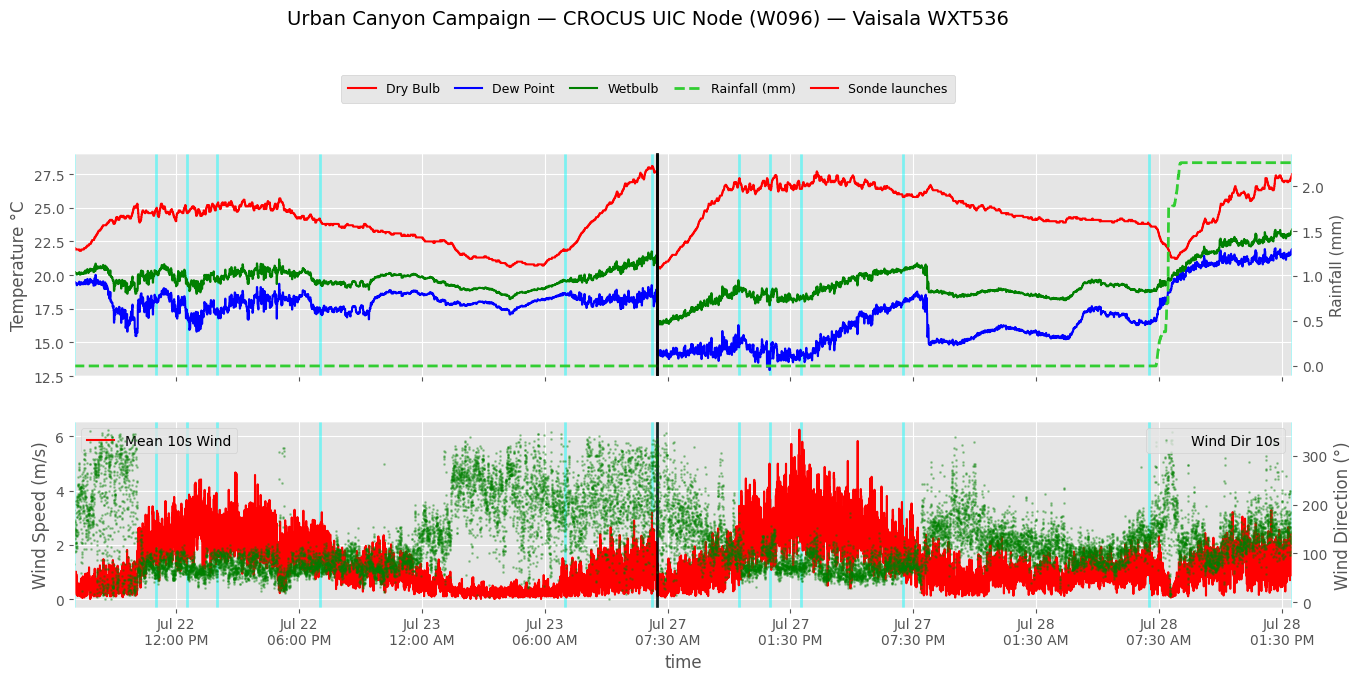

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.lines as mlines
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

plt.style.use("ggplot")
data = ds_all

TZ_LOCAL = "America/Chicago"

def utc_naive_to_local_naive(dt64_array, tz=TZ_LOCAL):
    """Assume numpy datetime64 array is UTC-naive; convert to local tz and drop tzinfo."""
    idx = pd.DatetimeIndex(dt64_array)
    return idx.tz_localize("UTC").tz_convert(tz).tz_localize(None)

# -------------------- IOP segments + splice (UTC) --------------------------
seg1 = data.sel(time=slice("2024-07-22T12:00:00", "2024-07-23T16:30:00")).copy()
seg2 = data.sel(time=slice("2024-07-27T12:00:00", "2024-07-28T19:00:00")).copy()

# Reset rainfall to zero at each IOP start
rain1 = seg1.rainfall - seg1.rainfall.isel(time=0)
rain2 = seg2.rainfall - seg2.rainfall.isel(time=0)

# Gap between IOPs (UTC)
gap_ns = seg2.time.min().values - seg1.time.max().values
gap_pd = pd.Timedelta(gap_ns)

# Shift seg2 backward by the gap so it splices right after seg1 (UTC)
seg2_shifted = seg2.assign_coords(time=seg2.time - gap_ns)

# Shift rainfall time coords to match
rain2_shifted = rain2.copy()
rain2_shifted["time"] = seg2_shifted.time

# Concatenate (UTC, spliced)
spliced = xr.concat([seg1, seg2_shifted], dim="time")
spliced_rain = xr.concat([rain1, rain2_shifted], dim="time")

# Accumulations for legend
ra1 = float(rain1.values[-1])
ra2 = float(rain2.values[-1])

# -------------------- Convert spliced axis to CDT/CST for plotting --------------------
spliced = spliced.assign_coords(time=("time", utc_naive_to_local_naive(spliced.time.values)))
spliced_rain = spliced_rain.copy()
spliced_rain["time"] = spliced.time  # keep aligned

# Reference times for vlines/annotations (LOCAL, on the spliced axis)
t_end_iop1 = utc_naive_to_local_naive([seg1.time.max().values])[0].to_pydatetime()
t_start_iop2 = utc_naive_to_local_naive([seg2_shifted.time.min().values])[0].to_pydatetime()  # <-- splice point

# Time bounds for tight xlim (LOCAL, spliced axis)
time_min = spliced.time.min().values
time_max = spliced.time.max().values

# -------------------- Plot setup --------------------
fig, (ax_temp, ax_wind) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]}
)

# --- Top: Temp, Dew, Wetbulb ---
l1 = spliced.temperature.plot(ax=ax_temp, color="r", label="Dry Bulb", zorder=2)
l2 = spliced.dewpoint.plot(ax=ax_temp, color="b", label="Dew Point", zorder=2)
l3 = spliced.wetbulb.plot(ax=ax_temp, color="g", label="Wetbulb", zorder=2)

# Twin y-axis for Rainfall
ax_rain = ax_temp.twinx()
l_rain, = ax_rain.plot(
    spliced_rain.time.values,
    spliced_rain.values,
    ls="--",
    color="limegreen",
    label="Rainfall (mm)",
    linewidth=2,
    zorder=2,
)
ax_rain.set_ylabel("Rainfall (mm)", fontsize=11)
ax_rain.tick_params(axis="y")
ax_rain.grid(False)

# Rainfall accumulation (legend-only)
h_ra1 = mlines.Line2D([], [], color="none", label=f"IOP1 Accum: {ra1:.2f} mm")
h_ra2 = mlines.Line2D([], [], color="none", label=f"IOP2 Accum: {ra2:.2f} mm")

# --- Bottom: Wind/Direction ---
l4 = spliced.wind_mean_10s.plot(ax=ax_wind, color="r", label="Mean 10s Wind", zorder=2)
yt = ax_wind.twinx()
l5 = spliced.wind_dir_10s.plot(
    ax=yt,
    color="g",
    label="Wind Dir 10s",
    marker=".",
    linestyle="none",
    markersize=2,
    alpha=0.3,
    zorder=2,
)
# ax_wind.set_title("Wind")
ax_wind.set_ylabel("Wind Speed (m/s)")
yt.set_ylabel("Wind Direction (°)")
ax_wind.legend(loc="upper left", fontsize=10)
yt.legend(loc="upper right", fontsize=10)
ax_wind.grid(True, zorder=0)
yt.grid(False)

# -------------------- Tick labels: show ORIGINAL (unspliced) dates in CDT, 12-hour AM/PM --------------------
def cdt_original_time_formatter(x, pos=None):
    dt_plot = mdates.num2date(x).replace(tzinfo=None)  # local-naive on spliced axis
    if dt_plot >= t_start_iop2:
        dt_orig = dt_plot + gap_pd
    else:
        dt_orig = dt_plot
    return dt_orig.strftime("%b %d\n%I:%M %p")  # 12-hour with AM/PM

for ax in (ax_temp, ax_wind, ax_rain):
    ax.xaxis.set_major_formatter(FuncFormatter(cdt_original_time_formatter))
    ax.set_xlim([time_min, time_max])

# -------------------- Sonde launch times (UTC strings -> shifted plot time -> local) --------------------
sonde_times = [
    "2024-07-22T12:00:00", "2024-07-22T16:00:00", "2024-07-22T17:30:00", "2024-07-22T19:00:00",
    "2024-07-23T00:00:00", "2024-07-23T12:00:00", "2024-07-23T16:15:00",
    "2024-07-27T12:00:00", "2024-07-27T16:00:00", "2024-07-27T17:30:00", "2024-07-27T19:00:00",
    "2024-07-28T00:00:00", "2024-07-28T12:00:00", "2024-07-28T19:00:00",
]

sonde_plot_times = []
for tstr in sonde_times:
    t_utc = pd.to_datetime(tstr)

    # Map IOP2 sondes onto the shifted UTC timeline
    if t_utc >= pd.to_datetime("2024-07-27T00:00:00"):
        idx = int(np.argmin(np.abs(seg2.time.values - np.datetime64(t_utc))))
        t_plot_utc = pd.to_datetime(seg2_shifted.time.values[idx])
    else:
        t_plot_utc = t_utc

    # Convert plotted UTC time to local (naive)
    t_plot_local = t_plot_utc.tz_localize("UTC").tz_convert(TZ_LOCAL).tz_localize(None)
    sonde_plot_times.append(t_plot_local)

sonde_line = None
for i, t_plot_local in enumerate(sonde_plot_times):
    label = "Sonde launches" if i == 0 else None
    for ax in (ax_temp, ax_wind):
        l = ax.axvline(
            t_plot_local, color="cyan", linestyle="-", linewidth=2, alpha=0.45, zorder=1, label=label
        )
        if label is not None:
            sonde_line = l

# -------------------- ONE splice line (add back) --------------------
# This is the exact point where IOP2 was stitched onto IOP1 (on the spliced CDT axis).
for ax in (ax_temp, ax_wind, ax_rain):
    ax.axvline(t_start_iop2, color="k", linewidth=2, alpha=0.85, zorder=6)

# -------------------- Titles + axes labels --------------------
# ax_temp.set_title("Temperature, Dewpoint, Wetbulb, Rainfall")
ax_temp.set_ylabel("Temperature °C")
ax_temp.set_xlabel("")
ax_temp.grid(True, zorder=0)

ymin = float(spliced.temperature.min()) - 8
ymax = float(spliced.temperature.max()) + 1
ax_temp.set_ylim(ymin, ymax)

# -------------------- Figure-level legend ABOVE the top panel --------------------
# -------------------- Figure-level legend ABOVE the top panel --------------------
handles = [l1[0], l2[0], l3[0], l_rain, l4[0], l5, sonde_line]
labels  = ["Dry Bulb", "Dew Point", "Wetbulb", "Rainfall (mm)", "Sonde launches"]

# Make extra top margin for a legend row + suptitle (so nothing overlaps)
fig.subplots_adjust(top=0.78, bottom=0.13, left=0.09, right=0.96, hspace=0.22)

leg = fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.90),
    ncol=7,          # <-- bumped to fit wind items
    fontsize=9,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    borderpad=0.6,
    handlelength=2.2,
    columnspacing=1.2,
)

# -------------------- Suptitle --------------------
wsn = spliced.WSN
fig.suptitle(
    f"Urban Canyon Campaign — CROCUS UIC Node ({wsn}) — Vaisala WXT536",
    y=0.985,
    fontsize=14,
)

plt.show()